# Act 2 — The Raw City

You are pointed to a single source: the NYC TLC trip records.
No clean datasets. No curated tables. Just trips, timestamps, locations, fares.

**Your task:** Define what a real trip looks like — and defend that definition.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_STABILITY='#2ecc71'; COLOR_STRESS='#e74c3c'; COLOR_CAUTION='#f39c12'; COLOR_NEUTRAL='#3498db'
FIGURES_DIR='figures'; DATA_DIR='data'
os.makedirs(FIGURES_DIR, exist_ok=True); os.makedirs(DATA_DIR, exist_ok=True)
MONTH_NAMES={1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
ANALYSIS_MONTHS=[7,8,9]; ANALYSIS_YEAR=2023
print('Setup done.')

Setup done.


In [2]:
BASE_URL='https://d37ci6vzurychx.cloudfront.net/trip-data'
ZONE_URL='https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
FILE_TEMPLATES={'yellow':'yellow_tripdata_{y}-{m:02d}.parquet','green':'green_tripdata_{y}-{m:02d}.parquet','hvfhv':'fhvhv_tripdata_{y}-{m:02d}.parquet'}

def download_file(url, dest):
    if os.path.exists(dest):
        print(f'  exists: {dest}'); return True
    try:
        print(f'  downloading {os.path.basename(dest)} ...')
        r=requests.get(url,stream=True,timeout=180); r.raise_for_status()
        with open(dest,'wb') as f:
            for chunk in r.iter_content(8192): f.write(chunk)
        print(f'  saved {dest}'); return True
    except Exception as e:
        print(f'  ERROR: {e}'); return False

for vtype,tmpl in FILE_TEMPLATES.items():
    for m in ANALYSIS_MONTHS:
        fname=tmpl.format(y=ANALYSIS_YEAR,m=m)
        download_file(f'{BASE_URL}/{fname}', os.path.join(DATA_DIR,fname))
zone_path=os.path.join(DATA_DIR,'taxi_zone_lookup.csv')
download_file(ZONE_URL, zone_path)
print('Downloads complete.')

  exists: data\yellow_tripdata_2023-07.parquet
  exists: data\yellow_tripdata_2023-08.parquet
  exists: data\yellow_tripdata_2023-09.parquet
  exists: data\green_tripdata_2023-07.parquet
  exists: data\green_tripdata_2023-08.parquet
  exists: data\green_tripdata_2023-09.parquet
  exists: data\fhvhv_tripdata_2023-07.parquet
  exists: data\fhvhv_tripdata_2023-08.parquet
  exists: data\fhvhv_tripdata_2023-09.parquet
  exists: data\taxi_zone_lookup.csv
Downloads complete.


In [3]:
# Cleaning rules applied to every chunk
def clean_chunk(df, vtype):
    # Rename columns to common schema
    renames={}
    if vtype=='yellow':
        renames={'tpep_pickup_datetime':'pickup_dt','tpep_dropoff_datetime':'dropoff_dt','PULocationID':'pu_loc','DOLocationID':'do_loc','trip_distance':'dist','total_amount':'total','fare_amount':'fare','tip_amount':'tip','payment_type':'pay_type','passenger_count':'pax'}
    elif vtype=='green':
        renames={'lpep_pickup_datetime':'pickup_dt','lpep_dropoff_datetime':'dropoff_dt','PULocationID':'pu_loc','DOLocationID':'do_loc','trip_distance':'dist','total_amount':'total','fare_amount':'fare','tip_amount':'tip','payment_type':'pay_type','passenger_count':'pax'}
    elif vtype=='hvfhv':
        renames={'pickup_datetime':'pickup_dt','dropoff_datetime':'dropoff_dt','PULocationID':'pu_loc','DOLocationID':'do_loc','trip_miles':'dist','base_passenger_fare':'fare'}
        df['total']=df.get('base_passenger_fare',pd.Series(dtype='float32'))
        df['tip']=df.get('tips',pd.Series(dtype='float32'))
    df=df.rename(columns=renames)

    # Keep only needed columns to save RAM
    keep=[c for c in ['pickup_dt','dropoff_dt','pu_loc','do_loc','dist','total','fare','tip','pay_type','pax'] if c in df.columns]
    df=df[keep].copy()

    # Parse datetimes
    df['pickup_dt']=pd.to_datetime(df['pickup_dt'],errors='coerce')
    df['dropoff_dt']=pd.to_datetime(df['dropoff_dt'],errors='coerce')

    # Filter to analysis window
    ws=pd.Timestamp(f'{ANALYSIS_YEAR}-{ANALYSIS_MONTHS[0]:02d}-01')
    we=pd.Timestamp(f'{ANALYSIS_YEAR}-{ANALYSIS_MONTHS[-1]:02d}-30 23:59:59')
    df=df[(df['pickup_dt']>=ws)&(df['pickup_dt']<=we)]

    # Compute duration
    df['dur_sec']=(df['dropoff_dt']-df['pickup_dt']).dt.total_seconds()

    # Apply cleaning rules
    df=df.dropna(subset=['pickup_dt','dropoff_dt','pu_loc','do_loc'])
    if 'dist' in df.columns: df=df[df['dist']>0]
    if 'total' in df.columns: df=df[df['total']>0]
    df=df[(df['dur_sec']>0)&(df['dur_sec']<=21600)]
    if 'dist' in df.columns: df=df[df['dist']<=200]

    df['vehicle_type']=vtype
    return df

print('Cleaning function defined.')

Cleaning function defined.


In [4]:
# Load one file at a time to avoid MemoryError
# Only keep essential columns when reading parquet
YELLOW_COLS=['tpep_pickup_datetime','tpep_dropoff_datetime','PULocationID','DOLocationID','trip_distance','total_amount','fare_amount','tip_amount','payment_type','passenger_count']
GREEN_COLS=['lpep_pickup_datetime','lpep_dropoff_datetime','PULocationID','DOLocationID','trip_distance','total_amount','fare_amount','tip_amount','payment_type','passenger_count']
HVFHV_COLS=['pickup_datetime','dropoff_datetime','PULocationID','DOLocationID','trip_miles','base_passenger_fare','tips']

COL_MAP={'yellow':YELLOW_COLS,'green':GREEN_COLS,'hvfhv':HVFHV_COLS}
TMPL_MAP={'yellow':'yellow_tripdata_{y}-{m:02d}.parquet','green':'green_tripdata_{y}-{m:02d}.parquet','hvfhv':'fhvhv_tripdata_{y}-{m:02d}.parquet'}

summary_rows=[]
cleaned_frames={'yellow':[],'green':[],'hvfhv':[]}

for vtype in ['yellow','green','hvfhv']:
    for m in ANALYSIS_MONTHS:
        fname=TMPL_MAP[vtype].format(y=ANALYSIS_YEAR,m=m)
        fpath=os.path.join(DATA_DIR,fname)
        if not os.path.exists(fpath):
            print(f'  SKIP (not found): {fname}'); continue
        try:
            # Read only needed columns — critical for RAM
            avail_cols=pd.read_parquet(fpath,engine='pyarrow').columns.tolist()
            use_cols=[c for c in COL_MAP[vtype] if c in avail_cols]
            raw=pd.read_parquet(fpath,columns=use_cols,engine='pyarrow')
            raw_count=len(raw)
            cleaned=clean_chunk(raw,vtype)
            del raw  # free RAM immediately
            cleaned_frames[vtype].append(cleaned)
            summary_rows.append({'vtype':vtype,'month':MONTH_NAMES[m],'raw':raw_count,'clean':len(cleaned)})
            print(f'  {vtype} {MONTH_NAMES[m]}: {raw_count:,} raw -> {len(cleaned):,} clean')
        except Exception as e:
            print(f'  ERROR {fname}: {e}')

# Combine months per vehicle type
yellow_clean=pd.concat(cleaned_frames['yellow'],ignore_index=True) if cleaned_frames['yellow'] else pd.DataFrame()
green_clean =pd.concat(cleaned_frames['green'], ignore_index=True) if cleaned_frames['green']  else pd.DataFrame()
hvfhv_clean =pd.concat(cleaned_frames['hvfhv'], ignore_index=True) if cleaned_frames['hvfhv']  else pd.DataFrame()

print(f'\nFinal: yellow={len(yellow_clean):,}  green={len(green_clean):,}  hvfhv={len(hvfhv_clean):,}')

  yellow Jul: 2,907,108 raw -> 2,826,829 clean


  yellow Aug: 2,824,209 raw -> 2,736,139 clean
  ERROR yellow_tripdata_2023-09.parquet: Could not open Parquet input source '<Buffer>': Couldn't deserialize thrift: TProtocolException: Invalid data

  green Jul: 61,343 raw -> 57,535 clean
  green Aug: 60,649 raw -> 56,899 clean
  green Sep: 65,471 raw -> 61,826 clean


  hvfhv Jul: 19,132,131 raw -> 19,128,154 clean


  hvfhv Aug: 18,322,150 raw -> 18,314,951 clean


  hvfhv Sep: 19,851,123 raw -> 19,844,984 clean



Final: yellow=5,562,968  green=176,260  hvfhv=57,288,089


 vtype month      raw    clean  pct_retained
yellow   Jul  2907108  2826829     97.238527
yellow   Aug  2824209  2736139     96.881605
 green   Jul    61343    57535     93.792283
 green   Aug    60649    56899     93.816881
 green   Sep    65471    61826     94.432650
 hvfhv   Jul 19132131 19128154     99.979213
 hvfhv   Aug 18322150 18314951     99.960709
 hvfhv   Sep 19851123 19844984     99.969075


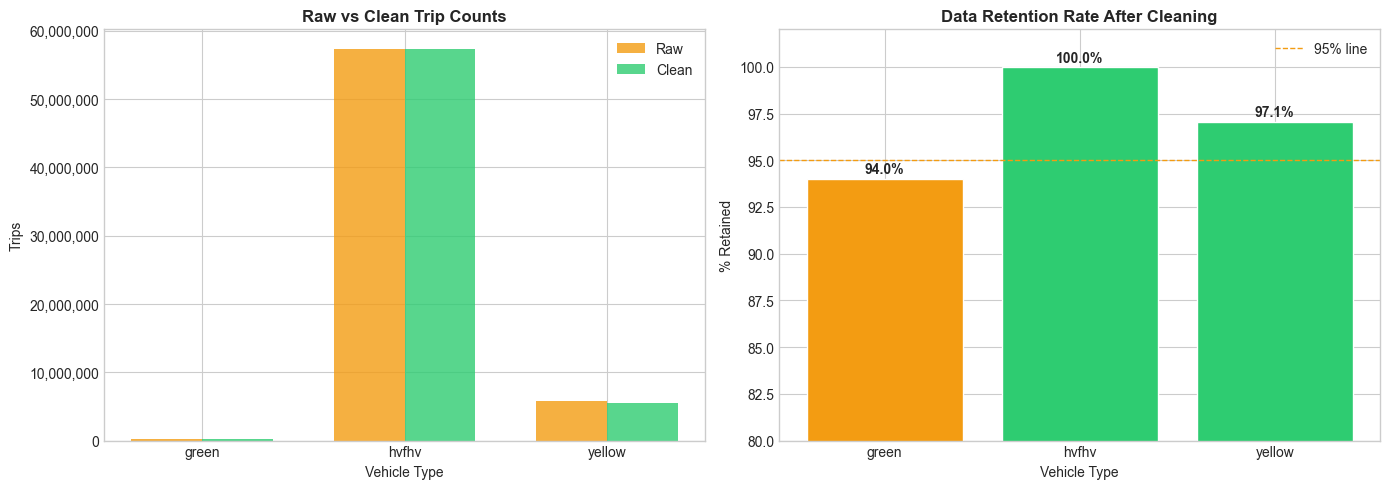

Figure saved to figures/act2_data_quality.png


In [5]:
# Data quality summary chart
sdf=pd.DataFrame(summary_rows)
if not sdf.empty:
    sdf['pct_retained']=sdf['clean']/sdf['raw']*100
    print(sdf[['vtype','month','raw','clean','pct_retained']].to_string(index=False))

    fig,axes=plt.subplots(1,2,figsize=(14,5))

    # Chart 1: raw vs clean per vehicle type
    totals=sdf.groupby('vtype')[['raw','clean']].sum().reset_index()
    x=np.arange(len(totals)); w=0.35
    axes[0].bar(x-w/2,totals['raw'],w,label='Raw',color=COLOR_CAUTION,alpha=0.8)
    axes[0].bar(x+w/2,totals['clean'],w,label='Clean',color=COLOR_STABILITY,alpha=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(totals['vtype'])
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:f'{int(v):,}'))
    axes[0].set_title('Raw vs Clean Trip Counts',fontweight='bold')
    axes[0].set_xlabel('Vehicle Type'); axes[0].set_ylabel('Trips')
    axes[0].legend()

    # Chart 2: retention rate
    ret=sdf.groupby('vtype')['pct_retained'].mean().reset_index()
    bar_colors=[COLOR_STABILITY if r>=95 else COLOR_CAUTION if r>=90 else COLOR_STRESS for r in ret['pct_retained']]
    bars=axes[1].bar(ret['vtype'],ret['pct_retained'],color=bar_colors,edgecolor='white')
    for bar,val in zip(bars,ret['pct_retained']):
        axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{val:.1f}%',ha='center',fontweight='bold')
    axes[1].set_ylim(80,102)
    axes[1].axhline(95,color=COLOR_CAUTION,linestyle='--',linewidth=1,label='95% line')
    axes[1].set_title('Data Retention Rate After Cleaning',fontweight='bold')
    axes[1].set_xlabel('Vehicle Type'); axes[1].set_ylabel('% Retained')
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/act2_data_quality.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {FIGURES_DIR}/act2_data_quality.png')

### Act 2 — Verdict: What Counts as a Real Trip?

Seven rules define a real trip:
- **Distance > 0** — a taxi that never moved is not a trip
- **Fare > 0** — no revenue means no real transaction
- **Duration > 0 and <= 6 hours** — physically impossible or parked meter
- **Distance <= 200 miles** — implausible for NYC
- **No null timestamps or location IDs** — cannot place the trip in time or space

The retention rate shows how much of the raw data survives. High retention (>95%) means the data is largely trustworthy. Lower retention signals systemic recording problems.

**`yellow_clean`, `green_clean`, `hvfhv_clean` are the foundation for all subsequent acts.**